<a href="https://colab.research.google.com/github/williamvalenciaK/proyectoCursoPrework/blob/master/ExamenFinal_ia_2025iiv1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Inteligencia Artificial. Examen Final

Instrucciones:
* Por favor, complete las tareas de este notebook. Deberá enviar este notebook, así como una versión en PDF, a la plataforma Univirtual.
* Para crear el PDF, vaya a Archivo > Descargar como. Puede exportar a PDF mediante Latex, o exportar a HTML y luego imprimir a PDF.
* Añada una explicación clara de su enfoque y una interpretación detallada de sus resultados para cada subpregunta. Para ello, utilice celdas Markdown.

* Añada a continuación los nombres de todos los miembros del equipo.

**Integrantes:**

1.   Integrante 1: Robert Nuñez Poma
2.   Integrante 2: William Gerardo Valencia Grey

# 1 Técnicas basadas en regiones para la segmentación de imágenes (4 puntos)


La segmentación de imágenes es el proceso de **asignar una etiqueta a cada píxel en una imagen** de modo que los píxeles con la misma etiqueta compartan ciertas características. Como consecuencia, se producen regiones cuyos píxeles tienen propiedades similares, por ejemplo: intensidad, color, textura o ubicación en la imagen. El resultado de la segmentación de imágenes puede ser:

* un conjunto de segmentos que cubren colectivamente toda la imagen (por ejemplo, umbralización),
* o un conjunto de contornos extraídos de la imagen (por ejemplo, detección de bordes).

<center><img src="https://drive.google.com/uc?id=1bfe7S0QrNhhXi9JAeBN_rxUf0xIEG3LK" width="550"/></center>

Conceptualmente, existen dos enfoques tradicionales para la segmentación de imágenes:

* **Segmentación de arriba hacia abajo (top-down)**, que considera que los píxeles del mismo objeto en la escena deben estar en la misma región segmentada.
* **Segmentación de abajo hacia arriba (bottom-up)**, que establece que los píxeles similares en la imagen deben estar en la misma región segmentada.

<center><img src="https://drive.google.com/uc?id=1ZJfa3d0zMFZHoKmeqfJpION7D2NLHNy0" width="500"/>

Imagen adaptada de <a href="myfootnote1">[1]</a></center>


Aquí ponemos el foco en los enfoques de segmentación de abajo hacia arriba. Los métodos que siguen este enfoque pueden agruparse en:

* **Técnicas basadas en contornos**, que intentan identificar las regiones de la imagen detectando sus contornos.
* **Técnicas basadas en regiones**, que agrupan píxeles que son similares entre sí.

En este notebook, cubriremos ambas familias de técnicas, comenzando con dos métodos populares basados en regiones:

* Expectation-Maximization


## Contexto del problema - Cuantización de color

<img src="https://drive.google.com/uc?id=13CLuIW7ZLOsyfBH7RdWBd_YkRa1mYgmG" width="800"/>

La cuantización de color es el proceso de reducir el número de colores distintos en una imagen mientras se preserva su apariencia de color lo mejor posible. Tiene muchas aplicaciones, como la compresión de imágenes (por ejemplo, GIFs) o [content-based image retrieval](https://en.wikipedia.org/wiki/Content-based_image_retrieval).


Las técnicas de segmentación de imágenes pueden utilizarse para lograr la cuantización de color, ¡veamos cómo funciona!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats as stats
from ipywidgets import interact, fixed, widgets
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
images_path = '/content/drive/MyDrive/PCs_IA/EF/ef2025iiv1.0/images/'

import sys
sys.path.append('/content/drive/MyDrive/PCs_IA/EF/ef2025iiv1.0')
from utils.PlotEllipse import PlotEllipse

## 1.1 K-Means (1.25 puntos)

Como se ha comentado, las técnicas basadas en regiones intentan agrupar los píxeles que son similares. Este problema suele denominarse *problema de agrupamiento*. Different attributes can be used to decide if two pixels are similar or not: intensity, texture, color, pixel location, etc.

El algoritmo **k-means** es una técnica basada en regiones que, dado un conjunto de elementos, crea $K$ clusters a partir de ellos. Por tanto, es una técnica perfecta para abordar la cuantificación del color, ya que nuestro objetivo es reducir la paleta de colores de una imagen a un número fijo de colores $K$.

Pero, **¿cómo funciona el algoritmo k-means** en un dominio de color, donde cada píxel está representado en un espacio n-dimensional? (e.g. las imágenes en escala de grises definen un espacio 1D, mientras que las imágenes RGB un espacio 3D):

1. Elige el número $K$, es decir, el número de clusters en los que se segmentará la imagen (por ejemplo, el número de colores).
2. Coloque $K$ centroides en el espacio de color (por ejemplo, al azar), estos son los centros de las regiones.
3. Cada píxel se asigna al cluster con el centroide más cercano, creando así nuevos clusters.

<center><img src="https://drive.google.com/uc?id=1QsM0yb2whX6B6qHFwyXWsrk1ap2KeNyW" width="400" align="center"/></center>

4. Calcular las nuevas medias de los clusters.

<center><img src="https://drive.google.com/uc?id=1o-YafIlq5-P7CB7hX8XobBR3KSY7lPpW" width="400" align="center"/>

<i>Ejemplo de evolución de los centroides a lo largo del tiempo</i></center>$\\[5pt]$

5. Repita los pasos 3 y 4 hasta la convergencia, es decir, algún criterio previamente definido se cumple

<center><img src="https://drive.google.com/uc?id=1nfQH1ddwWJsBUBD9rpDk1q48Qg-9Z-XZ" width="400" align="center"/>

<i>Resultado Final de la segmentación</i></center>$\\[5pt]$

El procedimiento es el mismo independientemente del número de dimensiones del espacio de trabajo.

Esta técnica presenta una serie de pros y contras:

- **Ventajas**
  - Es sencilla.
  - Se garantiza la convergencia a un mínimo local (pero no se garantiza alcanzar el mínimo global).
- **Desventajas:**
  - Alto consumo de memoria.
  - La K debe ser fija.
  - Sensible a la selección de la inicialización (posición inicial de centroides).
  - Sensible a outliers.
  - Se asumen clusters circulares en el espacio de características (debido al uso de la distancia euclidiana).
### K-means ejemplo de juguete

Por suerte para nosotros, OpenCV define un método que realiza k-means: [`cv2.kmeans()`](https://docs.opencv.org/2.4/modules/core/doc/clustering.html). Veamos un ejemplo de k-means 1D de juguete para familiarizarnos con él. La siguiente función, `binarize_kmeans()`, binariza una `imagen` de entrada ejecutando el algoritmo K-means, donde `it` establece el número máximo de iteraciones (representa el criterio de parada/convergencia).

In [ ]:
def binarize_kmeans(image,it):
    """ Binarize an image using k-means.

        Args:
            image: Input image
            it: K-means iteration
    """


    # Set random seed for centroids
    cv2.setRNGSeed(124)

    # Flatten image
    flattened_img = image.reshape((-1,1))
    flattened_img = np.float32(flattened_img)

    #Set epsilon
    epsilon = 0.2

    # Estabish stopping criteria (either `it` iterations or moving less than `epsilon`)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, it, epsilon)

    # Set K parameter (2 for thresholding)
    K = 2

    # Call kmeans using random initial position for centroids
    _,label,center=cv2.kmeans(flattened_img,K,None,criteria,it,cv2.KMEANS_RANDOM_CENTERS)

    # Colour resultant labels
    center = np.uint8(center)
    flattened_img = center[label.flatten()]

    # Reshape vector image to original shape
    binarized = flattened_img.reshape((image.shape))

    # Show resultant image
    plt.subplot(2,1,1)
    plt.title("Original image")
    plt.imshow(binarized, cmap='gray',vmin=0,vmax=255)

    # Show how original histogram have been segmented
    plt.subplot(2,1,2)
    plt.title("Segmented histogram")
    plt.hist([image[binarized==center[0]].ravel(), image[binarized==center[1]].ravel()],256,[0,256], color=["black","gray"],stacked="true")

Nótese que el criterio de parada puede ser o bien si se alcanza un número máximo de iteraciones, o bien si el centroide se mueve menos que un cierto valor de **epsión** en una iteración.

Como puede ver, [`cv2.kmeans()`](https://docs.opencv.org/2.4/modules/core/doc/clustering.html) devuelve dos argumentos relevantes:

- label: Matriz de enteros que almacena el índice del cluster para cada muestra.
- center: Matriz que contiene los centroides de los clusters (cada fila representa un centroide diferente).

A continuación se proporciona un código interactivo para que puedas jugar con `cv2.kmeans()` llamándolo con diferentes valores de `it`. Después de probarlo **se te pide que expliques** qué está haciendo `cv2.kmeans()` en cada iteración.

*Como puedes ver, si k=2 en una imagen en escala de grises, es un método de binarización que no necesita fijar un umbral manual.
Nótese que para espacios 1D y no para imágenes de alta resolución, ¡K-means es muy rápido! (sólo necesita unas pocas iteraciones para converger). ¿Qué ocurre si k-means se aplica con imágenes en color (espacio 3D) para obtener la cuantificación del color?  

Ahora que ya sabes cómo funciona k-means, puedes responder experimentalmente a esta pregunta.  
###  **<span style="color:green"><b><i>Problema 5.1: Jugando con K-means</i></b></span>**

Escribe un script que:
- aplique k-means a `malaga.png` con diferentes valores para $K$: $K=4$, $K=8$ y $K=16$,
- muestre, en un subplot de $2\times2$, las 3 imágenes resultantes junto con la de entrada.
<font color='blue'>**Salida Esperada:**  </font>

<img src="https://drive.google.com/uc?id=1PO_rfl69CwUZnHJ0F8j1QXx7rmO0xOmZ" width="800"/>

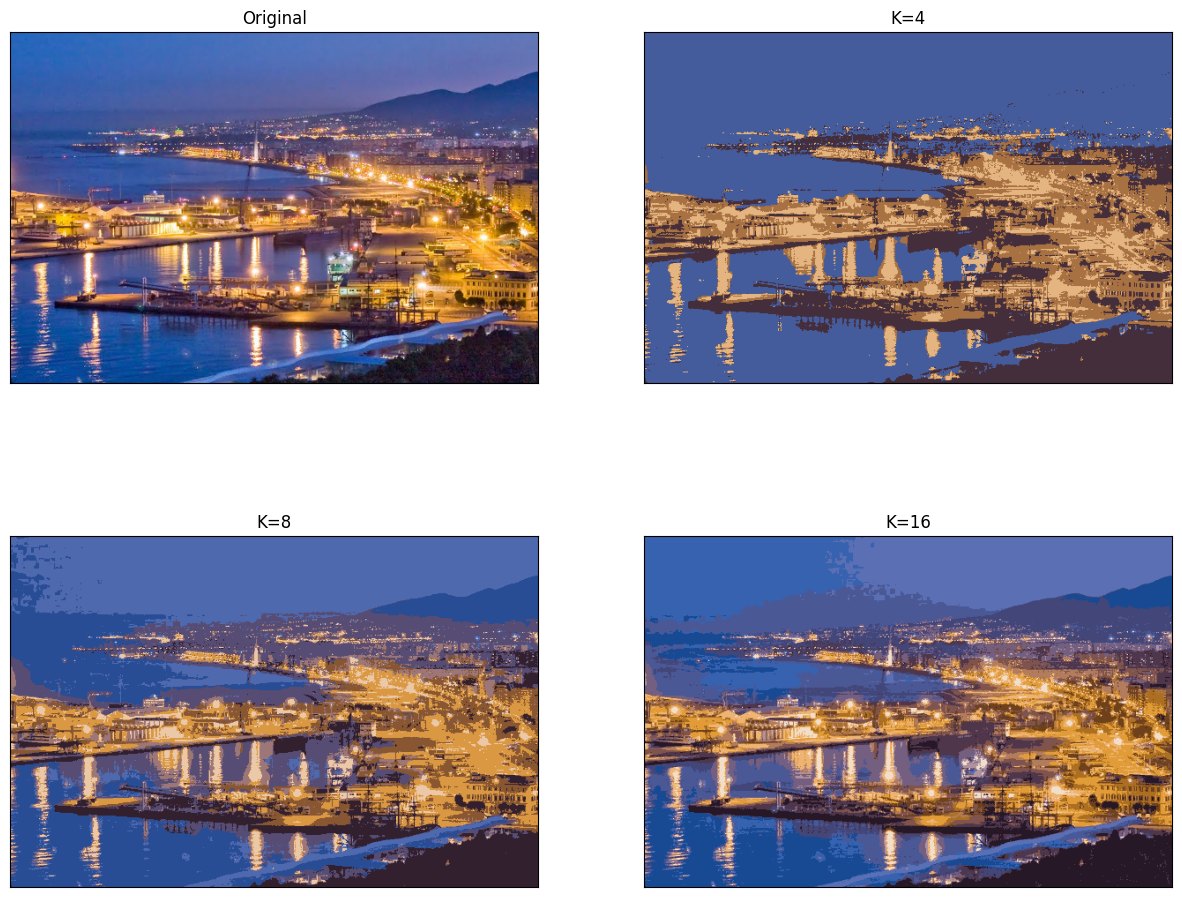

In [ ]:
matplotlib.rcParams['figure.figsize'] = (15.0, 12.0)

img = cv2.imread(images_path + 'malaga.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# k-means K=4
K = 4
_, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
segmented_image_4 = centers[labels.flatten()]
segmented_image_4 = segmented_image_4.reshape(img.shape)

# k-means K=8
K = 8
_, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
segmented_image_8 = centers[labels.flatten()]
segmented_image_8 = segmented_image_8.reshape(img.shape)

# k-means K=16
K = 16
_, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
segmented_image_16 = centers[labels.flatten()]
segmented_image_16 = segmented_image_16.reshape(img.shape)

plt.subplot(2,2,1)
plt.imshow(img)
plt.title('Original')
plt.xticks([]), plt.yticks([])

plt.subplot(2,2,2)
plt.imshow(segmented_image_4)
plt.title('K=4')
plt.xticks([]), plt.yticks([])

plt.subplot(2,2,3)
plt.imshow(segmented_image_8)
plt.title('K=8')
plt.xticks([]), plt.yticks([])

plt.subplot(2,2,4)
plt.imshow(segmented_image_16)
plt.title('K=16')
plt.xticks([]), plt.yticks([])

plt.show()

Ahora, **responde a las siguientes preguntas**:

- ¿Qué número de iteraciones máximas utilizaste? ¿Por qué?
  
  <p style="margin: 4px 0px 6px 5px; color:blue"><i>Utilicé un máximo de 100 iteraciones (<code>cv2.TERM_CRITERIA_MAX_ITER = 100</code>) y un epsilon de 0.2 (<code>cv2.TERM_CRITERIA_EPS = 0.2</code>). El algoritmo se detiene cuando se alcanza uno de estos dos umbrales. Un valor de 100 iteraciones es generalmente más que suficiente para que el algoritmo K-means converja a un mínimo local, especialmente cuando también se usa el criterio de épsilon. Este último detiene el proceso si el movimiento de los centroides es muy pequeño, lo que indica que la solución se ha estabilizado, haciendo el proceso más eficiente. Además, se usaron 10 intentos (<code>attempts=10</code>) para ejecutar el algoritmo con diferentes inicializaciones de centroides aleatorios, asegurando un resultado más robusto.</i></p>
    
- ¿Cómo sería posible comprimir estas imágenes? *Nota: considera que un píxel necesita 3 bytes para ser representado, 8 bits por banda.*.
  
    <p style="margin: 4px 0px 0px 5px; color:blue"><i>La compresión es posible al reducir la información de color que se necesita almacenar para cada píxel. En lugar de guardar el valor RGB de 24 bits (3 bytes) para cada píxel, podemos hacer lo siguiente:
    <br>1. <b>Almacenar la paleta de colores:</b> Se guarda la lista de los K colores de los centroides. Esto requiere `K * 3` bytes.
    <br>2. <b>Almacenar los índices de los píxeles:</b> Para cada píxel de la imagen, solo necesitamos guardar el índice (de 0 a K-1) del color en la paleta al que fue asignado. El número de bits necesarios para cada índice es `ceil(log2(K))`.
    <br><br>El tamaño total de la imagen comprimida sería aproximadamente `(K * 3) + (Ancho * Alto * ceil(log2(K)) / 8)` bytes. Para una imagen grande, este tamaño es ampliamente menor que el original `(Ancho * Alto * 3)` bytes.</i></p>
###  **<span style="color:green"><b><i>ASIGNACIÓN EXTRA: Analizar los tiempos de ejecucións</i></b></span>**

En este ejercicio se le pide que compare el tiempo de ejecución de K-means en una imagen en escala de grises, con K-means en una imagen RGB. Usa la imagen `malaga.png` para esta tarea, y usa el mismo número de clusters y criterios para ambas imágenes, la de escala de grises y la RGB.

*Sugerencia: [cómo medir el tiempo de ejecución en Python](https://stackoverflow.com/questions/14452145/how-to-measure-time-taken-between-lines-of-code-in-python)*

In [ ]:
import time

print("Midiendo el tiempo de ejecución necesario ...")

img_rgb = cv2.imread(images_path + 'malaga.png')
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
K = 8

# Escala de grises
start_gray = time.time()

pixel_values_gray = img_gray.reshape((-1, 1))
pixel_values_gray = np.float32(pixel_values_gray)

# k-means
_, _, _ = cv2.kmeans(pixel_values_gray, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

end_gray = time.time()
print(f"K-means en escala de grises tomó: {end_gray - start_gray:.4f} segundos")

# RGB
start_rgb = time.time()

pixel_values_rgb = img_rgb.reshape((-1, 3))
pixel_values_rgb = np.float32(pixel_values_rgb)

# k-means
_, _, _ = cv2.kmeans(pixel_values_rgb, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

end_rgb = time.time()
print(f"K-means en RGB tomó: {end_rgb - start_rgb:.4f} segundos")

Midiendo el tiempo de ejecución necesario ...
K-means en escala de grises tomó: 3.0566 segundos
K-means en RGB tomó: 9.8345 segundos


## 1.2 Expectation-Maximization (EM): (2.75 puntos)

**Expectation-Maximization (EM)** es la generalización del algoritmo K-means, donde cada clúster está representado por una distribución Gaussiana, parametrizada por una media y una matriz de covarianza, en lugar de solo un centroide. Es un *clustering suave* ya que no toma decisiones *duras* sobre si un píxel pertenece o no a un clúster, sino que calcula la probabilidad de que ese píxel pertenezca a cada clúster $C_j$, that is, $p(x|C_j) \sim N(\mu_j,\Sigma_j)$.  Esto implica que en cada iteración del algoritmo no solo se refina la media de cada clúster (como en K-means), sino también sus matrices de covarianza.

Antes de entrar en detalle sobre la teoría detrás de EM, vale la pena ver cómo se desempeña en el problema de la placa del auto. OpenCV proporciona una clase que implementa la funcionalidad necesaria para aplicar segmentación EM a una imagen, llamada [cv2.ml.EM](https://docs.opencv.org/3.4/d1/dfb/classcv_1_1ml_1_1EM.html). Todos los métodos y parámetros están completamente detallados en la documentación, por lo que es una buena idea echarle un vistazo.


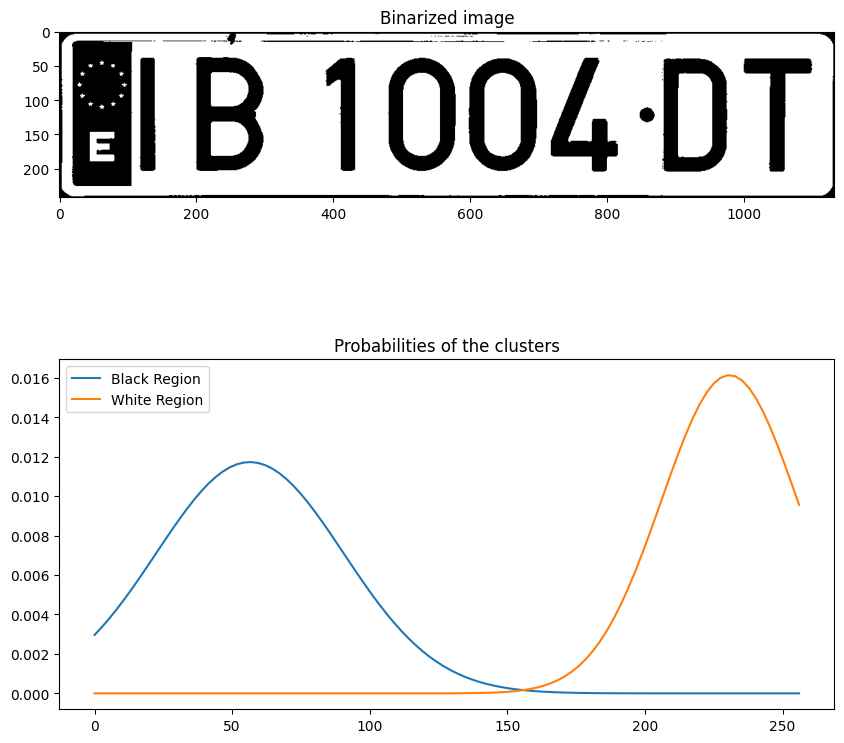

In [ ]:
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
cv2.setRNGSeed(5)

# Define parameters
n_clusters = 2
covariance_type = 0 # 0: covariance matrix spherical. 1: covariance matrix diagonal. 2: covariance matrix generic
n_iter = 10
epsilon = 0.2

# Create EM empty object
em = cv2.ml.EM_create()

# Set parameters
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, n_iter, epsilon)
em.setClustersNumber(n_clusters)
em.setCovarianceMatrixType(covariance_type)
em.setTermCriteria(criteria)

# Read grayscale image
image = cv2.imread(images_path + "plate.jpg",0)

# Flatten image
flattened_img = image.reshape((-1,1))
flattened_img = np.float32(flattened_img)

# Apply EM
_, _, labels, _ = em.trainEM(flattened_img)

# Reshape labels to image size (binarization)
binarized = labels.reshape((image.shape))

# Show original image
plt.subplot(2,1,1)
plt.title("Binarized image")
plt.imshow(binarized, cmap="gray")

# --------------- Gaussian visualization ---------------

plt.subplot(2,1,2)
plt.title("Probabilities of the clusters")

# Get means and covs (for grayscale 1D both)
means = em.getMeans()
covs = em.getCovs()

# Get standard deviation as numPy array
sigmas = np.sqrt(covs)
sigmas = sigmas[:,0,0]

# Cast list to numPy array
means = np.array(means)[:,0]

# Plot Gaussians
x = np.linspace(0, 256, 100)
plt.plot(x, stats.norm.pdf(x, loc = means[0], scale = sigmas[0]))
plt.plot(x, stats.norm.pdf(x, loc = means[1], scale = sigmas[1]))
plt.legend(['Black Region', 'White Region'])

plt.show()

Como puedes ver, aunque en OpenCV **k-means** está implementado como un método y **EM** como una clase, ambos operan de forma similar. En el ejemplo anterior, estamos segmentando una placa de automóvil en dos clústeres, y **cada clúster está definido por una distribución Gaussiana** (una distribución Gaussiana para la región negra y otra para la región blanca). Esta es la base de EM, pero **¿cómo funciona?**

EM es un algoritmo iterativo que se divide en dos pasos principales:

* Primero, **inicializa la media y la matriz de covarianza de cada uno de los \$K\$ clústeres**. Típicamente, se eligen al azar (\$\mu\_j\$, \$\Sigma\_j\$) y \$P(C\_j)\$ (probabilidad a priori) para cada clúster \$j\$.
* Luego, se mantiene iterando realizando los pasos de Expectación-Maximización hasta que se cumpla algún criterio de parada (por ejemplo, cuando no ocurre ningún cambio en una iteración completa):

  1. **Paso de Expectación:** calcular las probabilidades de que cada punto pertenezca a cada clúster, es decir, \$p(C\_j|x\_i), \forall i \in \text{data}\$:

  $$
  P(C_j|x_i)=\frac{p(x_i|C_j)p(C_j)}{p(x_i)}=\frac{p(x_i|C_j)p(C_j)}{\sum_i p(x_i|C_j)p(C_j)}
  $$

  Se asigna \$x\_i\$ al clúster \$C\_j\$ con la mayor probabilidad \$P(C\_j|x\_i)\$.
  
  2\. **Paso de Maximización:** se reestiman los parámetros de los clústeres ((\$\mu\_j\$, \$\Sigma\_j\$) y \$p(C\_j)\$) para cada clúster \$j\$ conociendo los resultados del paso de expectación, lo que también se conoce como *Estimación de Máxima Verosimilitud (MLE)*:

  $$
  \mu_j=\frac{\sum_i p(C_j|x_i)x_i}{\sum_i p(C_j|x_i)} \\
  \Sigma_j = \frac{\sum_i p(C_j|x_i)(x_i-\mu_j)(x_i-\mu_j)^T}{\sum_i p(C_j|x_i)} \\
  p(C_j)=\sum_i p(C_j|x_i)p(x_i)=\frac{\sum_i p(C_j|x_i)}{N}
  $$

  *Nota que si no se dispone de otra información, se considera que las probabilidades a priori son igualmente probables.*

<center><img src="https://drive.google.com/uc?id=1qNLb1c_orAqKXeqf8Cap3TpRX1sVlPjD" width="400" align="center">

<i>Ejemplo de una ejecución del algoritmo EM con dos clústeres, mostrando la evolución de sus distribuciones Gaussianas asociadas.</i></center>


¿No te recuerda al algoritmo K-means? **¿Cuál es la diferencia entre ellos?**

La principal diferencia es que **K-means utiliza la distancia euclidiana** para medir qué tan cerca está un punto de un clúster. En EM se utiliza una distancia en la que **cada dimensión se pondera** según la **matriz de covarianza** de cada clúster, lo que se conoce como **distancia de Mahalanobis**. Además, en K-means un punto de datos **pertenece o no** a un clúster, mientras que en EM un punto de datos tiene una **probabilidad mayor o menor** de pertenecer a un clúster. La siguiente tabla resume otras diferencias:


<table width="500px">
    <tr>
        <td style="text-align:center;"></td>
        <td style="text-align:center;"><b>K-means</b></td>
        <td style="text-align:center;"><b>EM</b></td>
    </tr>
    <tr>
        <td style="text-align:center;"><b>Representación del clúster</b></td>
        <td style="text-align:center;">Media</td>
        <td style="text-align:center;">Media y (co)varianza</td>
    </tr>
    <tr>
        <td style="text-align:center;"><b>Inicialización del clúster</b></td>
        <td style="text-align:center;">Selección aleatoria de K medias</td>
        <td style="text-align:center;">Inicialización de K distribuciones Gaussianas <br />($\mu_j$, $\Sigma_j$) y $P(C_j)$</td>
    </tr>
    <tr>
        <td style="text-align:center;"><b>Expectación:</b> <br /> Estimar el clúster de cada dato</td>
        <td style="text-align:center;">Asignar cada punto a la media más cercana</td>
        <td style="text-align:center;">Calcular $P(C_j|x_i)$</td>
    </tr>
    <tr>
        <td style="text-align:center;"><b>Maximización:</b> <br /> Reestimar los parámetros del clúster</td>
        <td style="text-align:center;">Calcular medias de los clústeres actuales</td>
        <td style="text-align:center;">Calcular nuevos ($\mu_j$, $\Sigma_j$) y $P(C_j)$ para cada clúster $j$</td>
    </tr>
</table>


Si aún tienes curiosidad sobre EM, puedes encontrar [aquí](https://www.youtube.com/watch?v=REypj2sy_5U) una explicación más detallada.


#### <font color="orange">Cápsula OpenCV</font>

Volviendo al código, al trabajar con EM debemos especificar un tipo de matriz de covarianza utilizando [`em.setCovarianceMatrixType()`](https://docs.opencv.org/3.4/d1/dfb/classcv_1_1ml_1_1EM.html#a8b383c62697eac9a972931674790f6cd). Además, cuando aplicas [`em.trainEM()`](https://docs.opencv.org/3.4/d1/dfb/classcv_1_1ml_1_1EM.html#a5a6a7badbc0c85a8c9fa50a41bf1bcd2), este no devuelve el centroide de los clústeres; es posible obtenerlos llamando a [`em.getMeans()`](https://docs.opencv.org/3.4/d1/dfb/classcv_1_1ml_1_1EM.html#acec62dd55c06711c81d741c2d96603d1).


### **<span style="color:green"><b><i>TAREA 2: Cuantización de color con el espacio de color YCrCb</i></b></span>**

En el siguiente ejemplo, la cuantización de color se realiza utilizando el espacio de color YCrCb (más información sobre este espacio en el apéndice 2) en lugar de RGB. De este modo, la cuantización de color se aplica solo a las dos bandas de color, omitiendo la banda en escala de grises. ¡Veamos cómo funciona!

**¿Qué hacer?** Entender y probar el siguiente código.


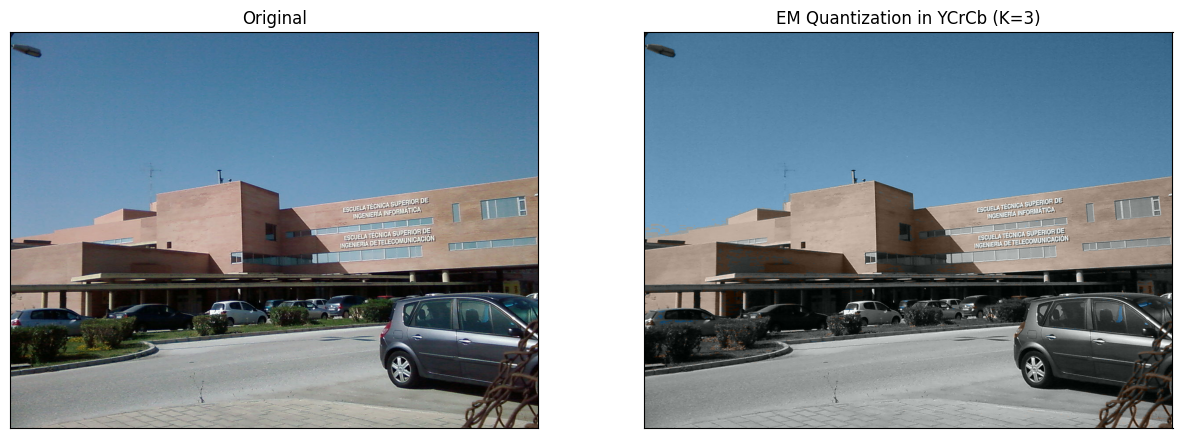

In [ ]:
# Assignment 2
matplotlib.rcParams['figure.figsize'] = (15.0, 15.0)
cv2.setRNGSeed(5)

# Define parameters
n_clusters = 3
covariance_type = 1 # 0: Spherical covariance matrix. 1: Diagonal covariance matrix. 2: Full covariance matrix
n_iter = 10
epsilon = 0.2

# Create EM empty object
em = cv2.ml.EM_create()

# Set parameters
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, n_iter, epsilon)
em.setClustersNumber(n_clusters)
em.setCovarianceMatrixType(covariance_type)
em.setTermCriteria(criteria)

# Read color image
img = cv2.imread(images_path + "etsii.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to YCrCb
img_ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)

# Take color bands (Cr and Cb)
color_bands = img_ycrcb[:,:,1:].astype(np.float32)

# Flatten image
flattened_color = color_bands.reshape(-1, 2)

# Apply EM
_, likelihood, labels, probs = em.trainEM(flattened_color)

# Colour resultant labels using the cluster centers (means)
centers = np.uint8(em.getMeans())
res = centers[labels.flatten()]

# Reshape to original shape
res = res.reshape(color_bands.shape)

# Merge original first band with quantized color bands
merged = np.zeros(img_ycrcb.shape)
merged[:,:,0] = img_ycrcb[:,:,0] # Original Y channel
merged[:,:,1] = res[:,:,0]      # Quantized Cr channel
merged[:,:,2] = res[:,:,1]      # Quantized Cb channel

# Cast to unsigned data type
merged = np.uint8(merged)

# Reconvert to RGB
res_rgb = cv2.cvtColor(merged, cv2.COLOR_YCrCb2RGB)

# Show original image
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original')
plt.xticks([]), plt.yticks([])

# Show resultant image
plt.subplot(1,2,2)
plt.imshow(res_rgb)
plt.title('EM Quantization in YCrCb (K=3)')
plt.xticks([]), plt.yticks([])

plt.show()

### <font color="blue"><b><i>Reflexionando sobre ello (2)</i></b></font>

Una vez que hayas entendido el código anterior, **responde las siguientes preguntas:**

* ¿Por qué los resultados obtenidos son tan buenos usando solo 3 clústeres?

    <p style="margin: 4px 0px 6px 5px; color:blue"><i>Los resultados son visualmente buenos porque la cuantización se realiza en el espacio de color YCrCb, separando la luminancia (intensidad, canal Y) de la crominancia (color, canales Cr y Cb). El algoritmo EM agrupa solo los componentes de color (CrCb), mientras que el canal de luminancia original se conserva intacto. La imagen `etsii.jpg` tiene áreas de color relativamente uniformes (cielo azul, edificio blanco/gris, vegetación verde), que pueden ser representadas adecuadamente por 3 clústeres de color sin perder la estructura principal de la imagen gracias a la preservación del canal Y.</i></p>

* ¿Qué compresión sería mejor en términos de espacio en memoria: una compresión a 16 colores en una imagen RGB o una compresión a 4 colores en una imagen YCrCb?

    <p style="margin: 4px 0px 0px 5px; color:blue"><i>Para determinar qué compresión es mejor en términos de espacio, comparamos el tamaño de almacenamiento requerido para cada método, asumiendo una imagen de ancho W y alto H. <br>1. <b>Compresión a 16 colores en RGB:</b> Se necesita una paleta para los 16 colores (`16 colores * 3 bytes/color = 48 bytes`). Para cada píxel, se guarda un índice que requiere `ceil(log2(16)) = 4` bits. El tamaño total es `(W * H * 4 bits) / 8 bits/byte + 48 bytes = 0.5 * W * H + 48` bytes. <br>2. <b>Compresión a 4 colores en YCrCb:</b> Se conserva el canal Y completo (`W * H * 1 byte`). Para los canales de color, se necesita una paleta para los 4 colores (`4 colores * 2 bytes/color = 8 bytes`) y un índice por píxel que requiere `ceil(log2(4)) = 2` bits. El tamaño total es `(W * H) + (W * H * 2 bits) / 8 bits/byte + 8 bytes = 1.25 * W * H + 8` bytes. <br><br><b>Conclusión:</b> La compresión a 16 colores en RGB (`0.5 * W * H`) ocupa menos espacio en memoria que la compresión a 4 colores en YCrCb manteniendo el canal Y completo (`1.25 * W * H`). Por lo tanto, en términos de espacio, la compresión en RGB es mejor.</i></p>


### Profundizando en las matrices de covarianza

Existen 3 tipos de matrices de covarianza: **covarianzas esféricas**, **covarianzas diagonales** o **covarianzas completas**:

<img src="https://drive.google.com/uc?id=1WyzZZGfj8iYbc2JrgrlPjIe2dh6pHOFZ" width="700" align="center">


### **<span style="color:green"><b><i>TAREA 3: Visualizando los clústeres con EM</i></b></span>**

A continuación, tienes un código para visualizar los clústeres en el espacio de color YCrCb utilizando EM.

**¿Qué hacer?** Ejecuta el ejemplo anterior modificando el tipo de covarianza en el algoritmo EM y visualiza los cambios utilizando el siguiente código.


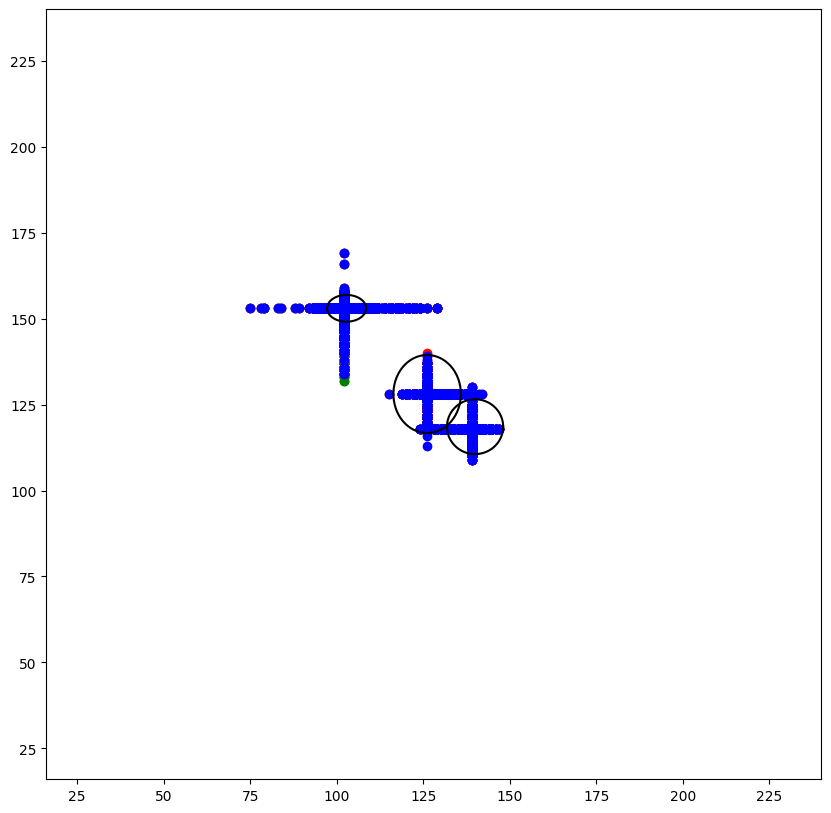

In [ ]:
# Assignment 3
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)

# Get means (2D) and covariance matrices (2x2)
means = np.array(em.getMeans())
covs = np.array(em.getCovs())

# Create figure
fig, ax = plt.subplots()
plt.axis([16, 240, 16, 240])

# Get points contained in each cluster
cluster_1 = np.any(color_bands == np.unique(res,axis=0)[0,:],axis=2)
cluster_2 = np.any(color_bands == np.unique(res,axis=0)[1,:],axis=2)
cluster_3 = np.any(color_bands == np.unique(res,axis=0)[2,:],axis=2)
cluster_1 = img_ycrcb[cluster_1]
cluster_2 = img_ycrcb[cluster_2]
cluster_3 = img_ycrcb[cluster_3]

# Plot them
plt.plot(cluster_1[:,1],cluster_1[:,2],'go')
plt.plot(cluster_2[:,1],cluster_2[:,2],'ro')
plt.plot(cluster_3[:,1],cluster_3[:,2],'bo')

# Plot ellipses representing covariance matrices
PlotEllipse(fig, ax, np.vstack(means[0,:]), covs[0,:,:], 2, color='black')
PlotEllipse(fig, ax, np.vstack(means[1,:]), covs[1,:,:], 2, color='black')
PlotEllipse(fig, ax, np.vstack(means[2,:]), covs[2,:,:], 2, color='black')

fig.canvas.draw()


### <font color="blue"><b><i>Reflexionando sobre ello (3)</i></b></font>

**Responde las siguientes preguntas** sobre cómo funciona el clustering en EM:

* ¿Cuáles son las diferencias entre cada tipo de covarianza?

    <p style="margin: 4px 0px 6px 5px; color:blue"><i>Esférica: misma varianza en todas las dimensiones, sin correlación → clústeres circulares/esféricos.

    Diagonal: varianzas distintas por dimensión, sin correlación → elipses alineadas con ejes, sin rotación.

    Genérica/Completa: varianzas distintas y correlación → elipses rotadas, máxima flexibilidad.</i></p>

* ¿Qué tipo de covarianza hace que EM sea equivalente a k-means?

    <p style="margin: 4px 0px 0px 5px; color:blue"><i>Esférica: porque k-means usa distancia euclidiana, que genera fronteras circulares y asignación dura.
    </i></p>



### **<span style="color:green"><b><i>TAREA 4: Aplicando EM considerando diferentes espacios de color</i></b></span>**

¡Es hora de demostrar lo que has aprendido sobre **EM** y **espacios de color**!

**¿Cuál es tu tarea?** Se te pide que **compares la cuantización de color en un espacio de color RGB y en un espacio de color YCrCb**.

Para ello:

* aplica el algoritmo Expectation-Maximization a `malaga.png` utilizando 4 clústeres (colores) tanto en la imagen en espacio RGB como en la imagen en espacio YCrCb,
* y muestra ambos resultados junto con la imagen original.


<font color='blue'>**Salida esperada:**  </font>

<img src="https://drive.google.com/uc?id=1HF4Ev5zzCKi84R55e-qqb8aUjeOZ1HL1" width="800"/>

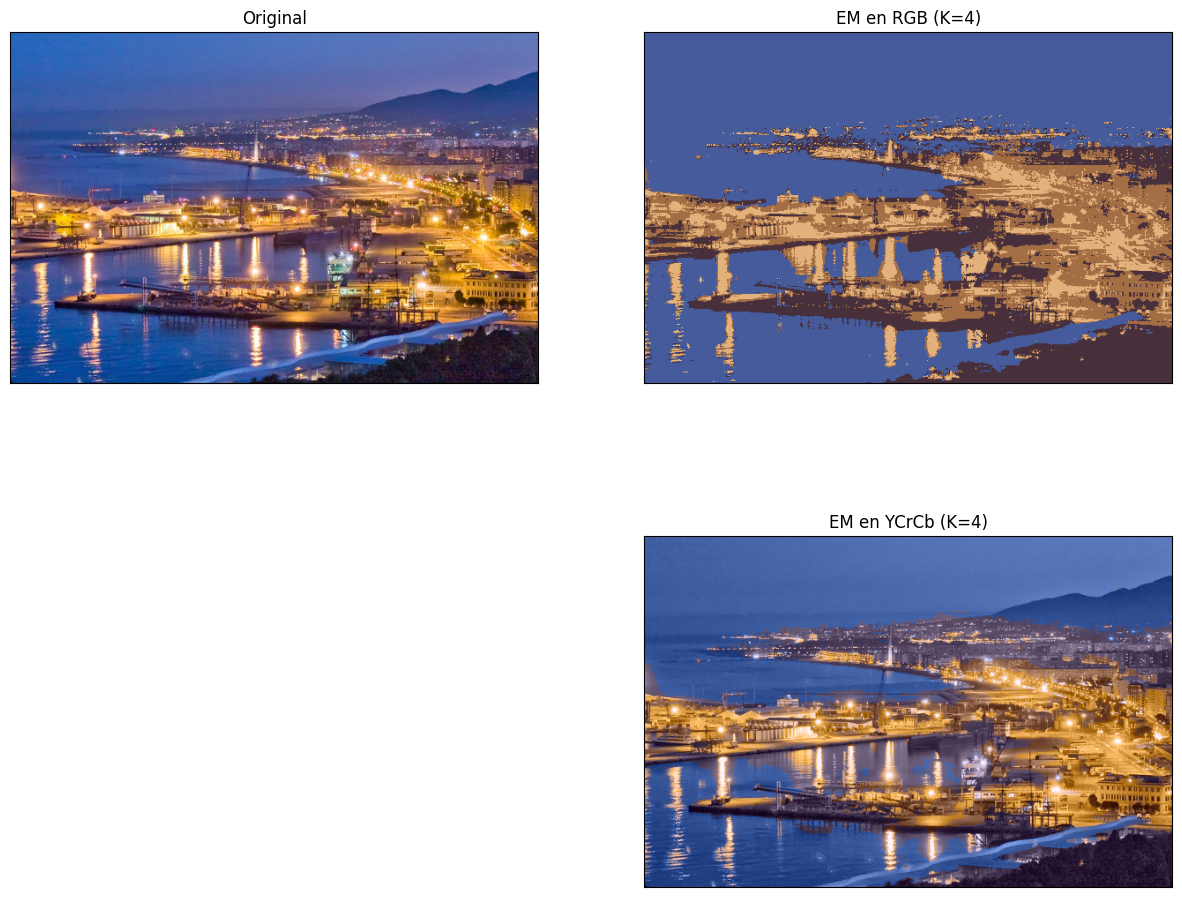

In [ ]:
# Assignment 4
matplotlib.rcParams['figure.figsize'] = (15.0, 12.0)
cv2.setRNGSeed(5)

# Define parameters
n_clusters = 4
covariance_type = 2 # 0: covariance matrix spherical. 1: covariance matrix diagonal. 2: covariance matrix generic
n_iter = 10
epsilon = 0.2

# --- Image Reading and Preprocessing ---

# Read image
img_bgr = cv2.imread(images_path + 'malaga.png')
# Convert image to RGB for display
img_rgb_orig = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# --- EM Quantization in RGB color space ---

# Create EM empty object for RGB
em_rgb = cv2.ml.EM_create()

# Set parameters
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, n_iter, epsilon)
em_rgb.setClustersNumber(n_clusters)
em_rgb.setCovarianceMatrixType(covariance_type)
em_rgb.setTermCriteria(criteria)

# Flatten RGB image
pixel_values_rgb = img_rgb_orig.reshape((-1, 3))
pixel_values_rgb = np.float32(pixel_values_rgb)

# Apply EM and get centers of clusters
_, _, labels_rgb, _ = em_rgb.trainEM(pixel_values_rgb)
centers_rgb = np.uint8(em_rgb.getMeans())

# Colour resultant labels
quantized_colors_rgb = centers_rgb[labels_rgb.flatten()]

# Reshape to original shape
img_quantized_rgb = quantized_colors_rgb.reshape(img_rgb_orig.shape)

# --- EM Quantization in YCrCb color space ---

# Create EM empty object for YCrCb
em_ycrcb = cv2.ml.EM_create()

# Set parameters
em_ycrcb.setClustersNumber(n_clusters)
em_ycrcb.setCovarianceMatrixType(covariance_type)
em_ycrcb.setTermCriteria(criteria)

# Convert image to YCrCb
img_ycrcb = cv2.cvtColor(img_rgb_orig, cv2.COLOR_RGB2YCrCb)

# Flatten color bands of YCrCb image
color_bands_ycrcb = img_ycrcb[:,:,1:].astype(np.float32)
flattened_color_ycrcb = color_bands_ycrcb.reshape(-1, 2)

# Apply EM
_, _, labels_ycrcb, _ = em_ycrcb.trainEM(flattened_color_ycrcb)
centers_ycrcb = np.uint8(em_ycrcb.getMeans())

# Colour resultant labels
quantized_colors_ycrcb = centers_ycrcb[labels_ycrcb.flatten()]

# Reshape to original color band shape
quantized_color_bands = quantized_colors_ycrcb.reshape(color_bands_ycrcb.shape)

# Merge original first band with quantized color bands for YCrCb image
merged_ycrcb = np.zeros(img_ycrcb.shape, dtype=np.uint8)
merged_ycrcb[:,:,0] = img_ycrcb[:,:,0]      # Original Y channel
merged_ycrcb[:,:,1] = quantized_color_bands[:,:,0] # Quantized Cr channel
merged_ycrcb[:,:,2] = quantized_color_bands[:,:,1] # Quantized Cb channel

# Reconvert YCrCb image back to RGB
img_quantized_ycrcb_rgb = cv2.cvtColor(merged_ycrcb, cv2.COLOR_YCrCb2RGB)


# --- Display Results ---

# Show original image
plt.subplot(2,2,1)
plt.imshow(img_rgb_orig)
plt.title('Original')
plt.xticks([]), plt.yticks([])

# Show resultant quantization using RGB color space
plt.subplot(2,2,2)
plt.imshow(img_quantized_rgb)
plt.title(f'EM en RGB (K={n_clusters})')
plt.xticks([]), plt.yticks([])

# Show resultant quantization using YCrCb color space
plt.subplot(2,2,4)
plt.imshow(img_quantized_ycrcb_rgb)
plt.title(f'EM en YCrCb (K={n_clusters})')
plt.xticks([]), plt.yticks([])

plt.show()

## Conclusión

¡Felicidades por haber completado este trabajo! Has aprendido:

* cómo funciona el clustering k-means y cómo utilizarlo,
* cómo se desempeña el algoritmo EM y cómo emplearlo,
* cómo realizar cuantización de color y la importancia de los espacios de color en este contexto, y
* algunos conceptos básicos sobre compresión de imágenes.

### Extra

Has utilizado YCrCb en este notebook porque ya estabas familiarizado con él. La verdad es que, en temas de cuantización de color, [Lab color space](https://en.wikipedia.org/wiki/CIELAB_color_space) es comúnmente utilizado.  

Busca información en internet sobre el espacio de color Lab y luego  **responde las siguientes preguntas:**:

- ¿Cómo funciona el espacio de color Lab?

  El espacio de color Lab es un modelo de color tridimensional que está independiente del dispositivo y está basado en la percepción visual humana . Sus coordenadas describen todos los colores visibles para el ojo humano y se componen de tres ejes:
  - $L$ (Luminosidad o Lightness): Este eje vertical representa el brillo del color. Va de 0 (negro) en la parte inferior a 100 (blanco) en la parte superior.
  - $a$ (Eje Rojo-Verde): Este eje horizontal representa la cromaticidad entre el verde y el rojo.
    - Valores positivos $(+a)$ indican rojo.
    - Valores negativos $(-a)$ indican verde.
  - $b$ (Eje Amarillo-Azul): Este eje horizontal representa la cromaticidad entre el azul y el amarillo.
    - Valores positivos $(+b)$ indican amarillo.
    - Valores negativos $(-b)$ indican azul.

  La gran ventaja del Lab es que las distancias matemáticas entre dos puntos de color en el espacio Lab se corresponden mejor con las diferencias de color que percibe el ojo humano.

- ¿Por qué se utiliza típicamente para la cuantización de color?

  El espacio de color Lab se utiliza típicamente para la cuantización de color debido a su característica clave: la uniformidad perceptual.
  - **Uniformidad Perceptual**: A diferencia de otros espacios de color como RGB o CMYK, en el espacio Lab, una misma distancia euclidiana entre dos colores ($\Delta E$, donde $\Delta E = \sqrt{(\Delta L)^2 + (\Delta a)^2 + (\Delta b)^2}$) representa, en teoría, el mismo cambio de color percibido por el ojo humano, independientemente de dónde se encuentre ese color en el espacio.
  - **Cuantización (Clustering)**: La cuantización de color a menudo implica agrupar colores similares (clustering) para reducir el número total de colores utilizados en una imagen. Si se utiliza un algoritmo como K-Means en el espacio Lab, la agrupación será más efectiva y el resultado visualmente más fiel. Esto se debe a que el algoritmo de clustering agrupa los colores basándose en la distancia matemática, y en Lab, esa distancia se correlaciona directamente con la percepción de similitud de color de una persona. Los clusters resultantes serán conjuntos de colores que realmente parecen similares a un observador humano.
  - **Independencia del Dispositivo**: Al ser independiente del dispositivo, actúa como un "lenguaje universal" del color, lo que permite describir y comunicar colores de forma objetiva, sin importar si provienen de una cámara, un monitor o una impresora.

# 2. Tarea: Clasificación de Imágenes (6 puntos)

En este ejercicio práctico resolverás un problema de clasificación de imágenes utilizando modelos profundos.

Los objetivos de esta tarea son:

* Desarrollar destreza en el uso de Keras para entrenar redes neuronales (NNs).
* Poner en práctica conocimientos generales de Machine Learning para optimizar los parámetros y la arquitectura de una red neuronal densa de avance directo (ffNN), en el contexto de un problema de visión por computadora.
* Utilizar redes neuronales especialmente concebidas para analizar imágenes. Diseñar y optimizar los parámetros de una red neuronal convolucional (cNN).
* Mejorar el rendimiento de una red neuronal mediante regularización y procesamiento de los datos a través de la red.


## A) Dense feed forward model (1.25 puntos)

Diseña y entrena una **ffNN** que resuelva el problema de clasificación planteado en la base de datos **Cifar-10**.

Como punto de partida en este proyecto, puedes utilizar el modelo proporcionado en los materiales del curso.

Debes mejorar los resultados obtenidos en los archivos de configuración de la red inicial. Para ello, debes decidir sobre:

* El número de capas y el número de unidades en cada capa.
* El algoritmo de optimización y los parámetros para entrenar la red.
* Revisar la evolución de estos parámetros durante la optimización y decidir cuándo detener el entrenamiento.


In [ ]:
# Load CIFAR-10 data set
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


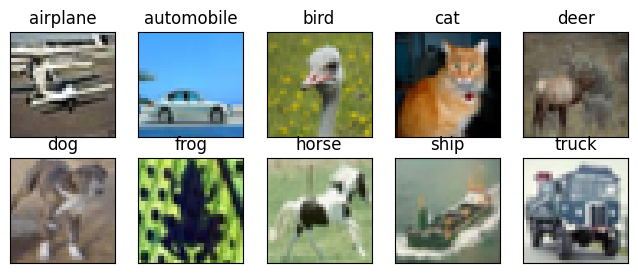

In [ ]:
# Show examples from each class
import numpy as np
import matplotlib.pyplot as plt

num_classes = len(np.unique(y_train))
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
fig = plt.figure(figsize=(8,3))
for i in range(num_classes):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    ax.set_title(class_names[i])
    idx = np.where(y_train[:]==i)[0]
    features_idx = X_train[idx,::]
    rnd_img = np.random.randint(features_idx.shape[0])
    im = np.transpose(features_idx[rnd_img,::], (0, 1, 2))
    plt.imshow(im)
plt.show()

In [ ]:
# Data pre-processing
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255.0
X_test /= 255.0

from tensorflow.keras.utils import to_categorical
Y_train = to_categorical(y_train, num_classes)
Y_test = to_categorical(y_test, num_classes)

In [ ]:
def plot_model_history(model_history):
    fig, axs = plt.subplots(1,2,figsize=(15,5))
    # Summarize history for accuracy
    axs[0].plot(range(1,len(model_history.history['accuracy'])+1),model_history.history['accuracy'])
    axs[0].plot(range(1,len(model_history.history['val_accuracy'])+1),model_history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    #axs[0].set_xticks(np.arange(1,len(model_history.history['accuracy'])+1),len(model_history.history['accuracy'])/10)
    axs[0].set_xticks(np.arange(1,len(model_history.history['accuracy'])+1))
    axs[0].legend(['train', 'val'], loc='best')
    # summarize history for loss
    axs[1].plot(range(1,len(model_history.history['loss'])+1),model_history.history['loss'])
    axs[1].plot(range(1,len(model_history.history['val_loss'])+1),model_history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    #axs[1].set_xticks(np.arange(1,len(model_history.history['loss'])+1),len(model_history.history['loss'])/10)
    axs[1].set_xticks(np.arange(1,len(model_history.history['loss'])+1))
    axs[1].legend(['train', 'val'], loc='best')
    plt.show()

In [ ]:
# Multilayer Perceptrons (MLPs)
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten

model = Sequential()
model.add(Flatten(input_shape=(32, 32, 3)))
model.add(Dense(10))
model.add(Activation('softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        30,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,730 (120.04 KB)

 Trainable params: 30,730 (120.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2719 - loss: 2.0399 - val_accuracy: 0.3299 - val_loss: 1.8806
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3553 - loss: 1.8394 - val_accuracy: 0.3584 - val_loss: 1.8229
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3666 - loss: 1.8077 - val_accuracy: 0.3862 - val_loss: 1.7663
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3828 - loss: 1.7805 - val_accuracy: 0.3813 - val_loss: 1.8030
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3835 - loss: 1.7741 - val_accuracy: 0.3843 - val_loss: 1.7636
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3872 - loss: 1.7681 - val_accuracy: 0.3868 - val_loss: 1.7656
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3890 - loss: 1.7629 - val_accuracy: 0.3597 - val_loss: 1.8793
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3882 - loss: 1.7589 - val_accuracy: 0.

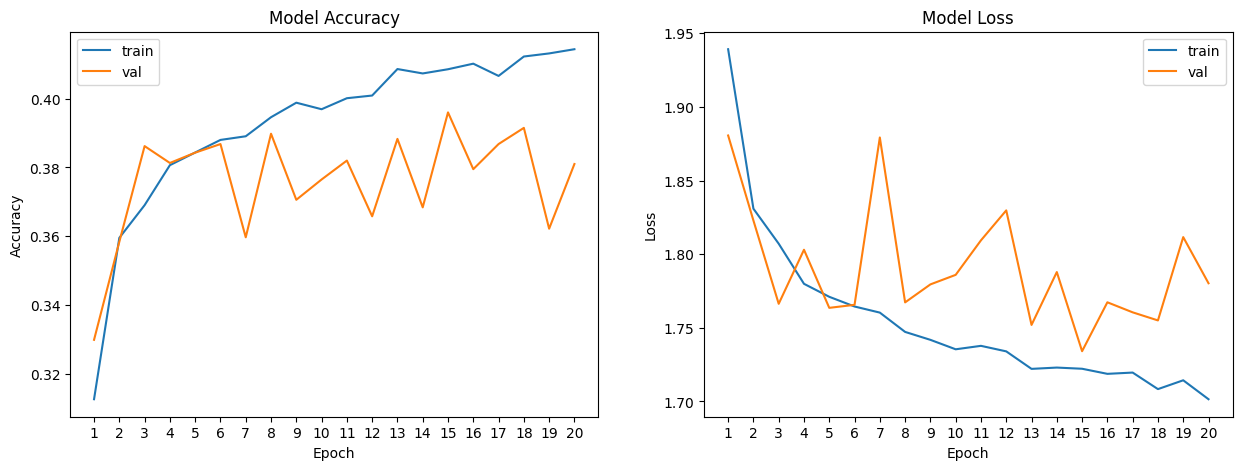

Training MLP took 40.326486110687256 seconds


In [ ]:
# Training
import time
start = time.time()
history = model.fit(X_train, Y_train, batch_size=128, epochs=20, verbose=1, validation_data=(X_test, Y_test))
end = time.time()

loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', acc)

plot_model_history(history)
print("Training MLP took " + str(end - start) + " seconds")

Se decidió realizar un modelo de tres capas Densas y de activación. Primero se inicia con una capa Flatten para aplanar la imagen en un vector. Luego, se pasa a la primera capa Dense de 512 neuronas para aprender las características de bajo nivel (bordes, texturas) directamente de los píxeles de entrada. Se pasa a la siguiente capa Dense donde se utiliza 256 neuronas para aprender características de nivel intermedio. Consecutivamente, le sigue un Dense con 128 neuronas para aprender las características de alto nivel. Finalmente, Se pasa a la capa de salida con softmax para clasificación multiclase.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.callbacks import EarlyStopping

# NUEVA ARQUITECTURA FFNN
model_mejorado = Sequential()

# La capa Flatten
model_mejorado.add(Flatten(input_shape=(32, 32, 3)))

# Primera Capa Densa y de Activación
model_mejorado.add(Dense(512, activation='relu'))


# Segunda Capa Densa y de Activación
model_mejorado.add(Dense(256, activation='relu'))


# Tercera Capa Densa y de Activación
model_mejorado.add(Dense(128, activation='relu'))

# Capa de Salida
model_mejorado.add(Dense(num_classes, activation='softmax'))

# Compilación del modelo
model_mejorado.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# Muestra el resumen del modelo mejorado
model_mejorado.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Para determinar hasta que época entrenar el modelo se definio un EarlyStopping que detiene el entrenamiento si val_accuracy no mejora por n épocas. Se probó con 10, 7 y 5 epócas de paciencia. Finalmente, se optó por 7 epócas de paciencia.

In [ ]:
# Training
# EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy',
                               patience=7,
                               restore_best_weights=True)

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.2584 - loss: 2.0486 - val_accuracy: 0.3870 - val_loss: 1.7237
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3913 - loss: 1.6948 - val_accuracy: 0.4076 - val_loss: 1.6408
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.4236 - loss: 1.6074 - val_accuracy: 0.4309 - val_loss: 1.6063
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.4525 - loss: 1.5377 - val_accuracy: 0.4514 - val_loss: 1.5300
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.4682 - loss: 1.4893 - val_accuracy: 0.4760 - val_loss: 1.4696
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.4836 - loss: 1.4473 - val_accuracy: 0.4704 - val_loss: 1.4832
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.4898 - loss: 1.4239 - val_accuracy: 0.4660 - val_loss: 1.5068
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5016 - loss: 1.

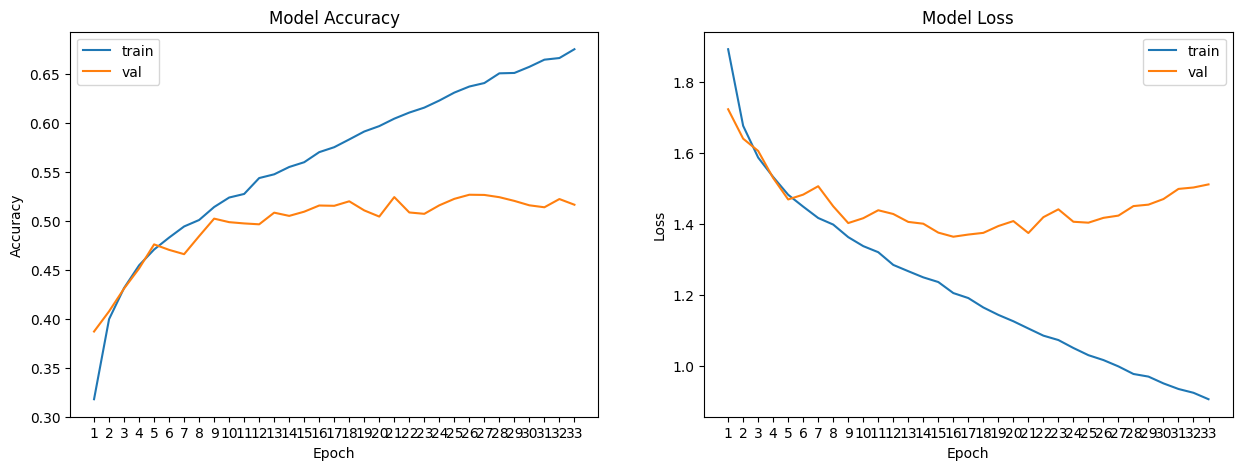

Training MLP mejorado took 339.7409245967865 seconds


In [ ]:
import time
start = time.time()

# Entrenar el modelo mejorado
history_mejorado = model_mejorado.fit(X_train, Y_train,
                                      batch_size=128,
                                      epochs=100, # Definir un número alto de épocas y dejar que EarlyStopping decida
                                      verbose=1,
                                      validation_data=(X_test, Y_test),
                                      callbacks=[early_stopping])

end = time.time()

# Evaluación
loss_mejorado, acc_mejorado = model_mejorado.evaluate(X_test, Y_test, verbose=0)
print('Test loss (Mejorado):', loss_mejorado)
print('Test accuracy (Mejorado):', acc_mejorado)

plot_model_history(history_mejorado)
print("Training MLP mejorado took " + str(end - start) + " seconds")

Como se puede observar la mejor epoca fue la número 26. Además que el nuevo modelo ha superado con creces al primer modelo tanto en mayor precisión y menor pérdida.

## B) Convolutional model (1.5 puntos)

Aquí experimentamos con **cNNs**, un tipo especial de red neuronal concebida para analizar imágenes. Utiliza **cNNs** para diseñar un nuevo modelo que supere los resultados de clasificación previos obtenidos en el conjunto de datos **Cifar-10**.


In [ ]:
# Convolutional Neural Network (CNN)
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
import keras.backend as K

model = Sequential()
model.add(Conv2D(filters=48, kernel_size=(3, 3), padding='same', input_shape=(32, 32, 3)))
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=96, kernel_size=(3, 3), padding='same'))
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Conv2D(filters=192, kernel_size=(3, 3), padding='same'))
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=32, kernel_size=(1, 1), padding='same'))
model.add(Activation('relu'))

model.add(Conv2D(filters=10, kernel_size=(4, 4), padding='valid'))
model.add(Flatten())
model.add(Activation('softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 48)     │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 192)      │       166,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 32)       │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 1, 10)       │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,298 (860.54 KB)

 Trainable params: 220,298 (860.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 200s 506ms/step - accuracy: 0.3342 - loss: 1.8018 - val_accuracy: 0.5285 - val_loss: 1.3201
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 200s 510ms/step - accuracy: 0.5681 - loss: 1.2140 - val_accuracy: 0.6201 - val_loss: 1.0812
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 198s 506ms/step - accuracy: 0.6371 - loss: 1.0405 - val_accuracy: 0.6538 - val_loss: 0.9887
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 196s 502ms/step - accuracy: 0.6829 - loss: 0.9155 - val_accuracy: 0.6865 - val_loss: 0.9110
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 205s 509ms/step - accuracy: 0.7164 - loss: 0.8213 - val_accuracy: 0.6943 - val_loss: 0.8794
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 200s 505ms/step - accuracy: 0.7309 - loss: 0.7831 - val_accuracy: 0.7123 - val_loss: 0.8362
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 198s 506ms/step - accuracy: 0.7554 - loss: 0.7062 - val_accuracy: 0.7202 - val_loss: 0.8162
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 205s 514ms/step - accuracy: 0.7725 -

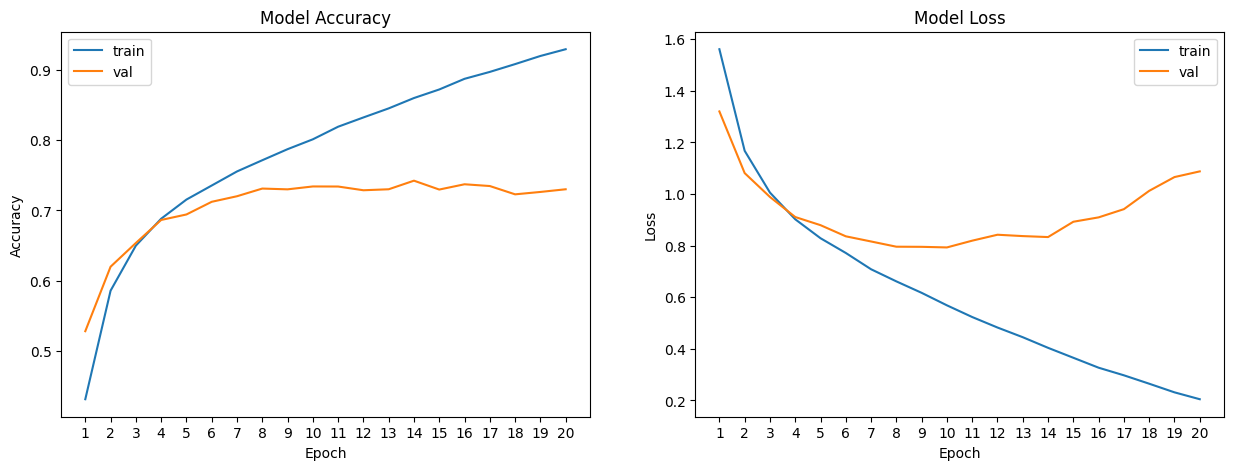

Training MLP took 4002.821564435959 seconds


In [ ]:
# Training
import time
start = time.time()
history = model.fit(X_train, Y_train, batch_size=128, epochs=20, verbose=1, validation_data=(X_test, Y_test))
end = time.time()

loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', acc)

plot_model_history(history)
print("Training MLP took " + str(end - start) + " seconds")

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, Dropout
from keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping

# NUEVA ARQUITECTURA CNN
model_cnn_mejorado = Sequential()

# Bloque 1: Aprendizaje de características de bajo nivel
model_cnn_mejorado.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', input_shape=(32, 32, 3)))
model_cnn_mejorado.add(Activation('relu'))
model_cnn_mejorado.add(Conv2D(filters=32, kernel_size=(3, 3)))
model_cnn_mejorado.add(Activation('relu'))
model_cnn_mejorado.add(MaxPooling2D(pool_size=(2, 2)))

# Bloque 2: Aprendizaje de características de nivel medio
model_cnn_mejorado.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same'))
model_cnn_mejorado.add(Activation('relu'))
model_cnn_mejorado.add(Conv2D(filters=64, kernel_size=(3, 3)))
model_cnn_mejorado.add(Activation('relu'))
model_cnn_mejorado.add(MaxPooling2D(pool_size=(2, 2)))

# Bloque 3: Aprendizaje de características de alto nivel
model_cnn_mejorado.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same'))
model_cnn_mejorado.add(Activation('relu'))
model_cnn_mejorado.add(Conv2D(filters=128, kernel_size=(3, 3)))
model_cnn_mejorado.add(Activation('relu'))
model_cnn_mejorado.add(MaxPooling2D(pool_size=(2, 2)))

# Capas Densas para Clasificación
model_cnn_mejorado.add(Flatten()) # Convierte el mapa de características 3D en un vector 1D
model_cnn_mejorado.add(Dense(512)) # Capa densa profunda para clasificación
model_cnn_mejorado.add(Activation('relu'))

# Capa de Salida
model_cnn_mejorado.add(Dense(num_classes))
model_cnn_mejorado.add(Activation('softmax')) # 10 clases, Softmax

# Compilación del modelo
model_cnn_mejorado.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# Muestra el resumen del modelo
model_cnn_mejorado.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 554,794 (2.12 MB)

 Trainable params: 554,794 (2.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 173s 441ms/step - accuracy: 0.9799 - loss: 0.0575 - val_accuracy: 0.7667 - val_loss: 1.3912
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 173s 443ms/step - accuracy: 0.9778 - loss: 0.0647 - val_accuracy: 0.7664 - val_loss: 1.3595
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 170s 435ms/step - accuracy: 0.9766 - loss: 0.0708 - val_accuracy: 0.7660 - val_loss: 1.4389
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 202s 435ms/step - accuracy: 0.9820 - loss: 0.0506 - val_accuracy: 0.7476 - val_loss: 1.5791
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 169s 433ms/step - accuracy: 0.9722 - loss: 0.0806 - val_accuracy: 0.7642 - val_loss: 1.5035
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 170s 436ms/step - accuracy: 0.9798 - loss: 0.0580 - val_accuracy: 0.7659 - val_loss: 1.5500
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 201s 434ms/step - accuracy: 0.9809 - loss: 0.0581 - val_accuracy: 0.7610 - val_loss: 1.5093
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 169s 431ms/step - accuracy: 0.9809 -

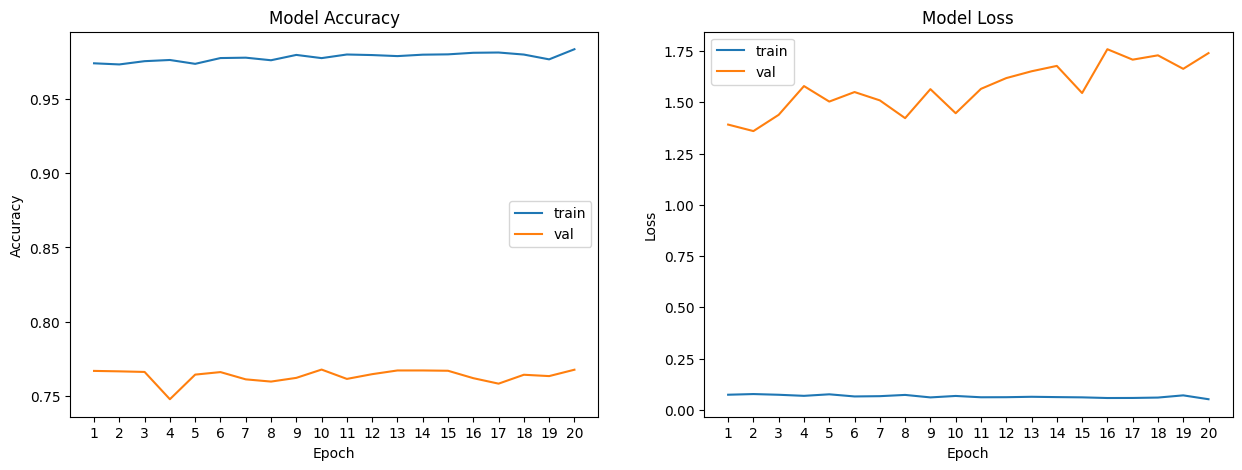

Training CNN mejorado took 3536.9254083633423 seconds


In [ ]:
import time
start = time.time()

# Entrenar el modelo
history_cnn_mejorado = model_cnn_mejorado.fit(X_train, Y_train,
                                      batch_size=128,
                                      epochs=20,
                                      verbose=1,
                                      validation_data=(X_test, Y_test))

end = time.time()

# Evaluación final
loss_cnn_mejorado, acc_cnn_mejorado = model_cnn_mejorado.evaluate(X_test, Y_test, verbose=0)
print('Test loss (CNN Mejorado):', loss_cnn_mejorado)
print('Test accuracy (CNN Mejorado):', acc_cnn_mejorado)

plot_model_history(history_cnn_mejorado)
print("Training CNN mejorado took " + str(end - start) + " seconds")

## C) Mejora de la Performance (1.75 puntos)

### Ejercicio C.1: Regularización

* Explora diferentes formas de regularizar tu modelo

  * Prueba añadiendo *dropout* después de cada capa de *MaxPooling* y de cada capa *Dense*.

    * ¿Cuáles son buenas tasas de *Dropout*? Prueba con una tasa fija de *Dropout* o aumenta las tasas en las capas más profundas.
  * Prueba la normalización por lotes (*batch normalization*) junto con *Dropout*

    * Piensa en qué lugares tendría sentido aplicar *batch normalization*
* Grafica e interpreta las curvas de aprendizaje


Nuestra FFNN ya es un modelo complejo con más de $1.7$ millones de parámetros. Usar una tasa alta podría reducir artificialmente la capacidad efectiva del modelo a la mitad, por lo tanto se eligio una tasa del 20%. El $20\%$ es un punto intermedio prudente en las capas densas internas. Proporciona suficiente ruido para forzar a la red a encontrar representaciones redundantes y robustas, sin sacrificar demasiado el flujo de información crucial.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.callbacks import EarlyStopping

# NUEVA ARQUITECTURA FFNN con DROPOUT
model_mejorado = Sequential()

# La capa Flatten
model_mejorado.add(Flatten(input_shape=(32, 32, 3)))

# Primera Capa Densa y de Activación
model_mejorado.add(Dense(512, activation='relu'))
model_mejorado.add(Dropout(0.2)) # Regularización para evitar el sobreajuste

# Segunda Capa Densa y de Activación
model_mejorado.add(Dense(256, activation='relu'))
model_mejorado.add(Dropout(0.2)) # Regularización para evitar el sobreajuste

# Tercera Capa Densa y de Activación
model_mejorado.add(Dense(128, activation='relu'))

# Capa de Salida
model_mejorado.add(Dense(num_classes, activation='softmax'))

# Compilación del modelo
model_mejorado.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# Muestra el resumen del modelo mejorado
model_mejorado.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training
# EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy',
                               patience=7,
                               restore_best_weights=True)

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.2299 - loss: 2.1042 - val_accuracy: 0.3482 - val_loss: 1.7917
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.3425 - loss: 1.8190 - val_accuracy: 0.3819 - val_loss: 1.7589
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.3503 - loss: 1.7890 - val_accuracy: 0.4083 - val_loss: 1.6738
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.3800 - loss: 1.7169 - val_accuracy: 0.4069 - val_loss: 1.6399
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.3909 - loss: 1.6854 - val_accuracy: 0.4320 - val_loss: 1.6094
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.4022 - loss: 1.6632 - val_accuracy: 0.4183 - val_loss: 1.6122
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.4078 - loss: 1.6452 - val_accuracy: 0.4351 - val_loss: 1.5901
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.4181 - loss: 1

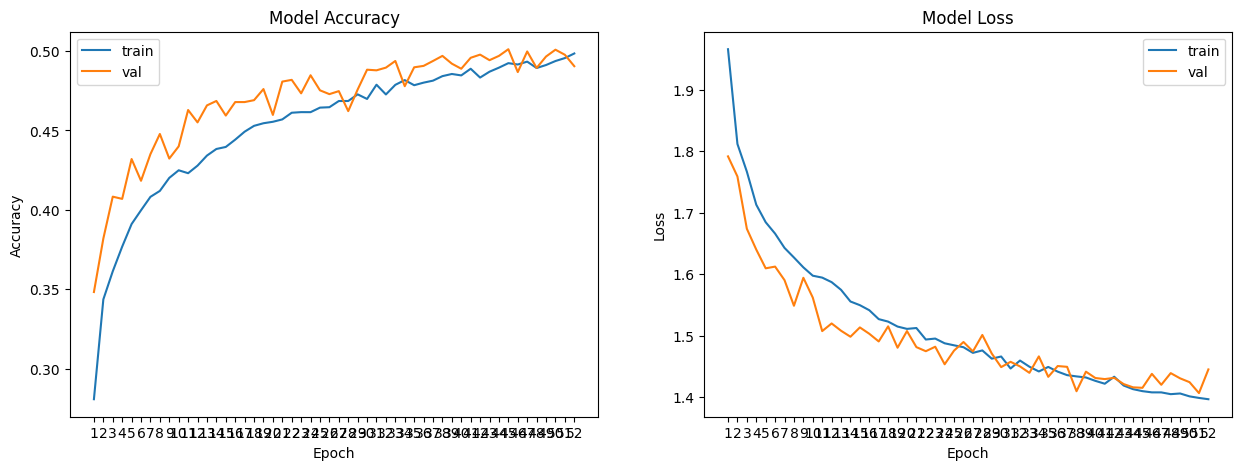

Training MLP mejorado took 750.3658385276794 seconds


In [ ]:
import time
start = time.time()

# Entrenar el modelo mejorado
history_mejorado = model_mejorado.fit(X_train, Y_train,
                                      batch_size=128,
                                      epochs=100, # Definir un número alto de épocas y dejar que EarlyStopping decida
                                      verbose=1,
                                      validation_data=(X_test, Y_test),
                                      callbacks=[early_stopping])

end = time.time()

# Evaluación
loss_mejorado, acc_mejorado = model_mejorado.evaluate(X_test, Y_test, verbose=0)
print('Test loss (Mejorado):', loss_mejorado)
print('Test accuracy (Mejorado):', acc_mejorado)

plot_model_history(history_mejorado)
print("Training MLP mejorado took " + str(end - start) + " seconds")

Como se puede observar el dropout mejoro el modelo al punto de llegar al 50% de precisión del modelo. El modleo puede aprender más pero se observa que a más epócas el modelo no mejorará más significativamente.

Ahora se procede a usar CNN con Batch Normalization (BN) y dropout. Se aplicará BN en los siguientes lugares:
- Después de cada capa `Conv2D`: Para estabilizar las salidas de la convolución antes de que pasen por la función de activación no lineal `ReLU`.
- Después de la capa `Dense` profunda: Para estabilizar las entradas de la capa de clasificación.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, Dropout
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization # Nueva capa
from tensorflow.keras.callbacks import EarlyStopping

# ARQUITECTURA CNN CON BATCH NORMALIZATION Y DROPOUT
model_cnn_bn = Sequential()

# Bloque 1
model_cnn_bn.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', input_shape=(32, 32, 3)))
model_cnn_bn.add(BatchNormalization()) # BN antes de la activación
model_cnn_bn.add(Activation('relu'))

model_cnn_bn.add(Conv2D(filters=32, kernel_size=(3, 3)))
model_cnn_bn.add(BatchNormalization())
model_cnn_bn.add(Activation('relu'))

model_cnn_bn.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn_bn.add(Dropout(0.25))

# Bloque 2
model_cnn_bn.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same'))
model_cnn_bn.add(BatchNormalization())
model_cnn_bn.add(Activation('relu'))

model_cnn_bn.add(Conv2D(filters=64, kernel_size=(3, 3)))
model_cnn_bn.add(BatchNormalization())
model_cnn_bn.add(Activation('relu'))

model_cnn_bn.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn_bn.add(Dropout(0.25))

# Bloque 3
model_cnn_bn.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same'))
model_cnn_bn.add(BatchNormalization())
model_cnn_bn.add(Activation('relu'))

model_cnn_bn.add(Conv2D(filters=128, kernel_size=(3, 3)))
model_cnn_bn.add(BatchNormalization())
model_cnn_bn.add(Activation('relu'))

model_cnn_bn.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn_bn.add(Dropout(0.25))

# Capas Densas para Clasificación
model_cnn_bn.add(Flatten())
model_cnn_bn.add(Dense(512))
model_cnn_bn.add(BatchNormalization()) # BN en la capa densa
model_cnn_bn.add(Activation('relu'))
model_cnn_bn.add(Dropout(0.5))

# Capa de Salida
model_cnn_bn.add(Dense(num_classes))
model_cnn_bn.add(Activation('softmax'))

# Muestra el resumen del modelo
model_cnn_bn.summary()

# COMPILACIÓN Y ENTRENAMIENTO
model_cnn_bn.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 4, 4, 128)      │             

 Total params: 558,634 (2.13 MB)

 Trainable params: 556,714 (2.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 225s 566ms/step - accuracy: 0.3331 - loss: 1.9596 - val_accuracy: 0.1867 - val_loss: 3.2998
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 218s 557ms/step - accuracy: 0.5655 - loss: 1.2127 - val_accuracy: 0.5770 - val_loss: 1.1873
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 233s 483ms/step - accuracy: 0.6498 - loss: 0.9763 - val_accuracy: 0.6158 - val_loss: 1.1446
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 204s 488ms/step - accuracy: 0.7031 - loss: 0.8333 - val_accuracy: 0.6749 - val_loss: 0.9341
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 202s 487ms/step - accuracy: 0.7312 - loss: 0.7590 - val_accuracy: 0.7195 - val_loss: 0.8210
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 193s 495ms/step - accuracy: 0.7577 - loss: 0.6901 - val_accuracy: 0.7284 - val_loss: 0.7763
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 192s 490ms/step - accuracy: 0.7723 - loss: 0.6452 - val_accuracy: 0.7763 - val_loss: 0.6596
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 199s 482ms/step - accuracy: 0.7910 -

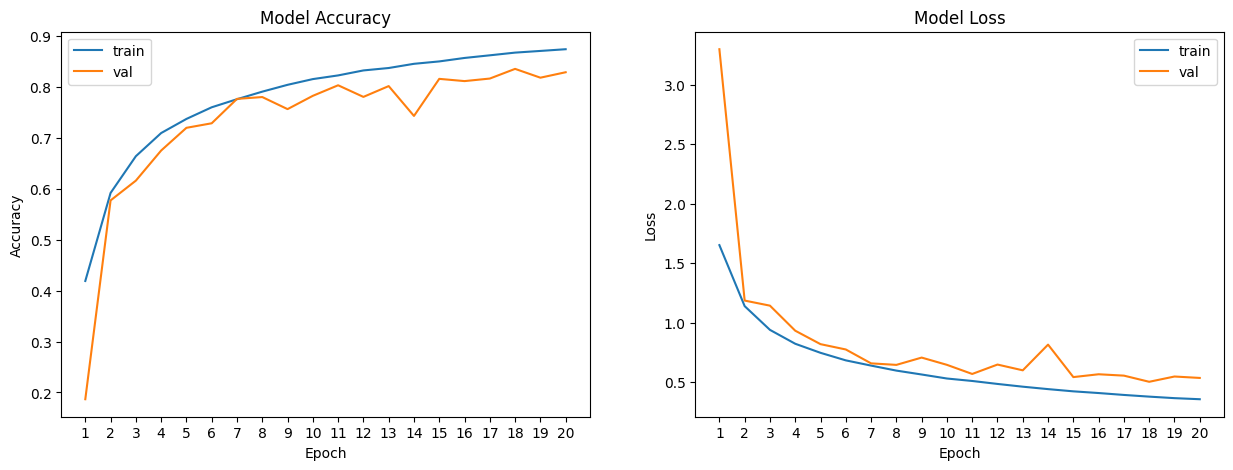

Training CNN con Batch Normalization took 4051.6854469776154 seconds


In [ ]:
import time
start = time.time()

# Entrenar el modelo
history_cnn_bn = model_cnn_bn.fit(X_train, Y_train,
                                  batch_size=128,
                                  epochs=20,
                                  verbose=1,
                                  validation_data=(X_test, Y_test))

end = time.time()

# Evaluación final
loss_cnn_bn, acc_cnn_bn = model_cnn_bn.evaluate(X_test, Y_test, verbose=0)
print('Test loss (CNN + BN):', loss_cnn_bn)
print('Test accuracy (CNN + BN):', acc_cnn_bn)

plot_model_history(history_cnn_bn)
print("Training CNN con Batch Normalization took " + str(end - start) + " seconds")

Se observa que el modelo mejoró significativamente en comparación del modelo anterior sin BN y Dropout.

### Ejercicio C.2: Data Augmentation

* Realiza aumento de imágenes (rotación, desplazamiento, cizalladura, zoom, volteo, etc.). Puedes utilizar **ImageDataGenerator** para esto.
* ¿Cuál es el efecto? ¿Cuál es el efecto con y sin *Dropout*?
* Grafica e interpreta las curvas de aprendizaje.


In [ ]:
!pip install keras

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import time

# CONFIGURACIÓN DEL GENERADOR DE DATOS

# Definición del generador con aumento de imágenes
datagen = ImageDataGenerator(
    rotation_range=15,             # Rotación aleatoria de hasta 15 grados
    width_shift_range=0.1,         # Desplazamiento horizontal aleatorio (10% del ancho)
    height_shift_range=0.1,        # Desplazamiento vertical aleatorio (10% del alto)
    shear_range=0.1,               # Inclinación (cizalladura) aleatoria
    zoom_range=0.1,                # Zoom aleatorio
    horizontal_flip=True,          # Volteo horizontal aleatorio
    fill_mode='nearest'            # Estrategia para rellenar píxeles nuevos (cercano)
)

# El generador se ajusta solo a los datos de entrenamiento
datagen.fit(X_train)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.2413 - loss: 2.0874 - val_accuracy: 0.3640 - val_loss: 1.7843
Epoch 2/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3125 - loss: 1.9279 - val_accuracy: 0.3758 - val_loss: 1.7571
Epoch 3/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.3562 - loss: 1.7933 - val_accuracy: 0.3893 - val_loss: 1.7027
Epoch 4/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3125 - loss: 1.7968 - val_accuracy: 0.4023 - val_loss: 1.6686
Epoch 5/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.3782 - loss: 1.7278 - val_accuracy: 0.4236 - val_loss: 1.6041
Epoch 6/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3906 - loss: 1.7744 - val_accuracy: 0.4293 - val_loss: 1.5936
Epoch 7/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.4040 - loss: 1.6657 - val_accuracy: 0.4387 - val_loss: 1.5586
Epoch 8/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3438 - loss: 1.7038 - val_accu

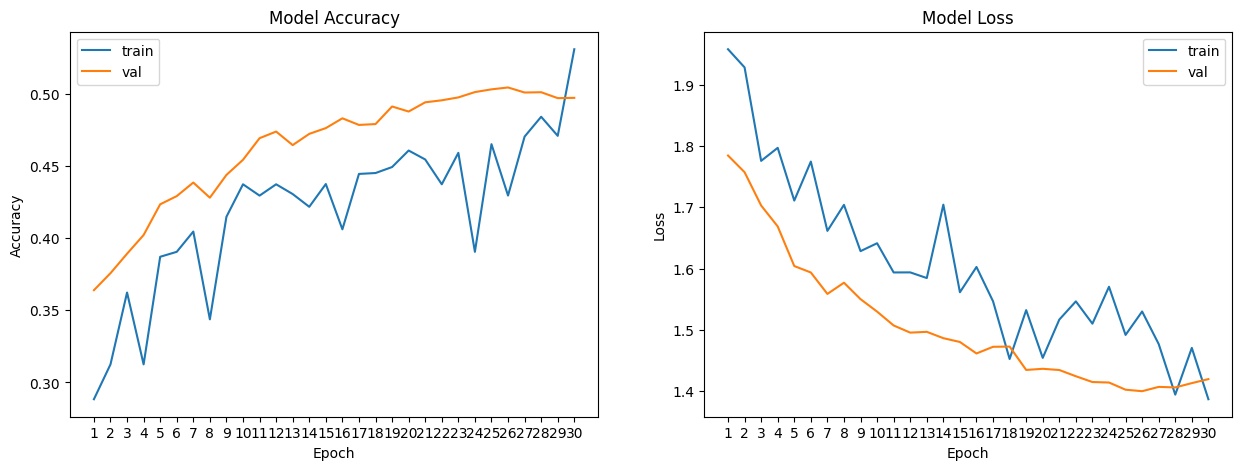

Training A tomó 488.03 segundos


In [ ]:
# A. FFNN MEJORADA SIN DROPOUT
def build_ffnn_no_dropout(num_classes):
    model = Sequential()
    model.add(Flatten(input_shape=(32, 32, 3)))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    return model

model_ffnn_no_drop = build_ffnn_no_dropout(num_classes)
model_ffnn_no_drop.compile(optimizer='adam',
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])
model_ffnn_no_drop.summary()

# Entrenamiento A: FFNN SIN Dropout + Aumento de Imágenes
start_a = time.time()
history_ffnn_no_drop_aug = model_ffnn_no_drop.fit(
    datagen.flow(X_train, Y_train, batch_size=128),
    epochs=30,
    verbose=1,
    validation_data=(X_test, Y_test),
    steps_per_epoch=len(X_train) // 128
)
end_a = time.time()

loss_a, acc_a = model_ffnn_no_drop.evaluate(X_test, Y_test, verbose=0)
print('Test accuracy (FFNN No Drop + Aug):', acc_a)
plot_model_history(history_ffnn_no_drop_aug)
print(f"Training A tomó {end_a - start_a:.2f} segundos")

Se nota una reducción de la brecha entre entrenamiento y validación, lo que nos indica que este modelo capta mejor las características de las imagénes. Pero tiene el defecto de necesitar más epócas de entrenamiento para superar al modelo original.

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 31s 76ms/step - accuracy: 0.2072 - loss: 2.1575 - val_accuracy: 0.3342 - val_loss: 1.8430
Epoch 2/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2969 - loss: 1.9140 - val_accuracy: 0.3437 - val_loss: 1.8244
Epoch 3/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.2953 - loss: 1.9206 - val_accuracy: 0.3733 - val_loss: 1.7518
Epoch 4/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3906 - loss: 1.7645 - val_accuracy: 0.3712 - val_loss: 1.7541
Epoch 5/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.3255 - loss: 1.8549 - val_accuracy: 0.3950 - val_loss: 1.7170
Epoch 6/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3516 - loss: 1.7737 - val_accuracy: 0.3943 - val_loss: 1.7182
Epoch 7/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.3314 - loss: 1.8269 - val_accuracy: 0.3930 - val_loss: 1.6867
Epoch 8/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2891 - loss: 1.9569 - val_accu

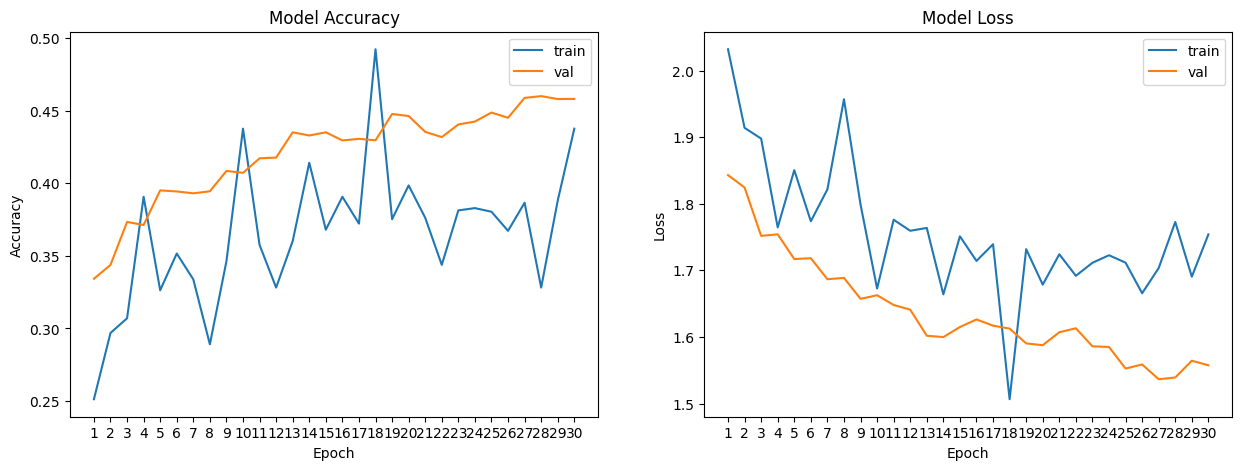

Training B tomó 478.61 segundos


In [ ]:
# B. FFNN MEJORADA CON DROPOUT
def build_ffnn_with_dropout(num_classes):
    model = Sequential()
    model.add(Flatten(input_shape=(32, 32, 3)))
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.2)) # Dropout
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.2)) # Dropout
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    return model

model_ffnn_with_drop = build_ffnn_with_dropout(num_classes)
model_ffnn_with_drop.compile(optimizer='adam',
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])
model_ffnn_with_drop.summary()

# Entrenamiento B: FFNN CON Dropout + Aumento de Imágenes
start_b = time.time()
history_ffnn_with_drop_aug = model_ffnn_with_drop.fit(
    datagen.flow(X_train, Y_train, batch_size=128),
    epochs=30,
    verbose=1,
    validation_data=(X_test, Y_test),
    steps_per_epoch=len(X_train) // 128
)
end_b = time.time()

loss_b, acc_b = model_ffnn_with_drop.evaluate(X_test, Y_test, verbose=0)
print('Test accuracy (FFNN Con Drop + Aug):', acc_b)
plot_model_history(history_ffnn_with_drop_aug)
print(f"Training B tomó {end_b - start_b:.2f} segundos")

Se observa que al usar el modelo con dropout el entrenamiento es errático pero la validación es ligeramente estable. No se recomienda usar ambos metódos en un solo modelo debido a la necesidad de más epócas para mejorar su precisión como la precisión errática del modelo en su entrenamiento.

### Ejercicio C.3: Mejoras Finales

Mejora el rendimiento de tus redes neuronales regularizando y preprocesando los datos a través de la red. Utiliza cualquier combinación de técnicas de regularización o procedimientos de procesamiento de datos para mejorar el rendimiento de tu **ffNN** y **cNN**.


## D) Reporte (1.5 puntos)

Redacta un informe describiendo:

* el problema (brevemente);
* las arquitecturas finales de las redes y el rendimiento final (precisión y pérdida) obtenido con los cuatro modelos (**ffNN**, **ffNN+mejora**, **cNN**, **cNN+mejora**) en los conjuntos de datos de entrenamiento y prueba;
* gráficos de la evolución de los costos y del rendimiento de clasificación en ambos conjuntos de datos para cada arquitectura;
* el proceso que has seguido para llegar a tu solución final;
* discute tus resultados.


# Informe: Clasificación de Imágenes CIFAR-10 con Redes Neuronales Profundas

## 1. Introducción al Problema

El objetivo ha sido diseñar y entrenar modelos de redes neuronales artificiales capaces de resolver el problema de **clasificación de imágenes** multi-clase utilizando el conjunto de datos **CIFAR-10**.

**CIFAR-10** es una base de datos estándar que consta de 60,000 imágenes en color ($32 \times 32$ píxeles) distribuidas en 10 clases (avión, coche, pájaro, gato, ciervo, perro, rana, caballo, barco, camión). El desafío radica en que los objetos están incrustados en escenas reales, lo que requiere que el modelo aprenda características espaciales complejas.

## 2. Desarrollo de Arquitecturas y Rendimiento

Se experimentó con cuatro arquitecturas distintas, evolucionando desde una Red Neuronal de Alimentación Directa (FFNN) simple hasta una profunda Red Neurales Convolucional (CNN) con técnicas de regularización avanzadas.

### A. Resumen de Arquitecturas y Rendimiento Final

| Modelo | Tipo de Red | Parámetros Totales | Precisión de Entrenamiento | Pérdida de Entrenamiento | Precisión de Prueba (`val_accuracy`) | Pérdida de Prueba (`val_loss`) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **1. FFNN Base** | FFNN | 30,730 | $41.82\%$ | $1.70$ | $38.10\%$ | $1.78$ |
| **2. FFNN Mejorada** | FFNN | 1,738,890 | $64.27\%$ | $1.00$ | $52.67\%$ | $1.42$ |
| **3. FFNN Mejorada + Drop** | FFNN | 1,738,890 | $49.26\%$ | $1.41$ | $50.12\%$ | $1.42$ |
| **4. CNN Base** | CNN | 220,298 | $93.41\%$ | $1.96$ | $73.01\%$ | $1.09$ |
| **5. CNN Mejorada** | CNN | 554,794 | $98.49\%$ | $0.05$ | $76.75\%$ | $1.74$ |
| **6. CNN Mejorada + BN + Drop** | CNN | 558,634 | $87.81\%$ | $0.35$ | $82.86\%$ | $0.54$ |

### B. Arquitecturas Finales Detalladas

#### **Modelo 3: FFNN Mejorada + Dropout (Resultado: $50.12\%$ de Precisión)**

Se aumentó la capacidad del modelo a tres capas densas (`Dense`) con regularización de `Dropout` para superar las limitaciones de la arquitectura base.



| Capa | Tipo de Capa | Salida | Parámetros |
| :--- | :--- | :--- | :--- |
| 1 | `Flatten` | 3072 | 0 |
| 2 | `Dense` + `ReLU` | 512 | 1,573,376 |
| 3 | `Dropout` | 512 | 0 |
| 4 | `Dense` + `ReLU` | 256 | 131,328 |
| 5 | `Dropout` | 256 | 0 |
| 6 | `Dense` + `ReLU` | 128 | 32,896 |
| 7 | `Dense` + `Softmax` | 10 | 1,290 |
| **Total** | | | **1,738,890** |

#### **Modelo 6: CNN Mejorada con Batch Normalization + Dropout (Resultado: $82.86\%$ de Precisión)**

Arquitectura profunda basada en bloques convolucionales, diseñada para extraer características espaciales de las imágenes de CIFAR-10.

| Capa | Configuración Clave | Función Principal |
| :--- | :--- | :--- |
| **Bloques CNN** | `Conv2D` (32, 64, 128 filtros) | Extracción jerárquica de características de la imagen (bordes, texturas, formas). |
| **Normalización** | `BatchNormalization` (BN) | Se aplica **antes** de `ReLU` para estabilizar la distribución de activaciones, acelerando la convergencia y mejorando la estabilidad. |
| **Regularización** | `Dropout` (0.25 y 0.5) | Se aplica después de `MaxPooling` y en las capas densas para prevenir el sobreajuste. |
| **Clasificación** | `Flatten` $\to$ `Dense(512)` $\to$ `Dense(10, Softmax)` | Traduce los mapas de características a las 10 probabilidades de clase. |

## 3. Análisis de resultados

#### Modelo 3

1.  **Limitación Arquitectónica:** La precisión máxima del $50.12\%$ subraya la insuficiencia de la FFNN. La capa `Flatten` al inicio destruye la información espacial crucial para distinguir las 10 clases de CIFAR-10. La red simplemente no tiene la capacidad de interpretar los datos de imagen correctamente.
2.  **Efecto de `Dropout`:** El modelo muestra un *subajuste* de entrenamiento ($-0.86\%$) , donde la precisión de entrenamiento es ligeramente inferior a la de prueba. Esto indica que el `Dropout` está funcionando de manera muy agresiva en un modelo que ya está limitado arquitectónicamente, forzando una generalización muy conservadora. El modelo está bien regularizado, pero su capacidad de aprendizaje está comprometida.

#### Modelo 6
1.  **Superioridad de la CNN:** La precisión de $82.86\%$ demuestra que las capas convolucionales son intrínsecamente mejores para extraer características espaciales invariantes (como bordes y texturas), lo que permite al modelo interpretar correctamente el contenido de la imagen.
2.  **Control del Sobreajuste:** La brecha de sobreajuste se redujo a solo $4.95\%$. Esto es un indicio de que el modelo está aprendiendo características robustas y no solo memorizando, lo que se traduce directamente en la alta precisión de prueba.

## 3. Conclusión
El **Modelo CNN Mejorado con Batch Normalization y Dropout** es la arquitectura final recomendada, ya que equilibra efectivamente la capacidad del modelo para aprender características complejas con las técnicas de regularización necesarias para garantizar una alta capacidad de generalización en datos no vistos.

## References

<a name="myfootnote1">[1]</a>: Borenstein, Eran, Eitan Sharon, and Shimon Ullman. [Combining top-down and bottom-up segmentation.](http://www.wisdom.weizmann.ac.il/~vision/courses/2006_2/papers/recog_seg/Borenstein%20combining%20top-down%20and%20bottom-up%20segmentation.pdf). IEEE Conference on Conference on Computer Vision and Pattern Recognition Workshop, 2004.